# [Hands-On] Mastering LLaMA 2: A Complete Walkthrough from Scratch

- Author: Sangkeun Jung (hugmanskj@gmail.com)

> Educational Purpose

**Copyright**: All rights reserved

---
### Overview
The purpose of this lecture is to extend the complete LLaMA 1 implementation to LLaMA 2. In the previous sections, we built LLaMA 1 from the ground up.

In this lecture, we will compare LLaMA 1 with LLaMA 2, focusing on the core feature of Grouped Query Attention (GQA). We will implement LLaMA 2 by adding GQA to the LLaMA 1 codebase and verify whether the LLaMA 2 model operates correctly.

We begin by implementing essential utility functions, such as data loading, model initialization, and training helper functions. These components will be reused across different experimental setups for consistency and efficiency.

In [ ]:
## Importing Libraries

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd

## Hyperparameters and Configuration

In [ ]:
# Modified hyperparameters
SEQUENCE_LENGTH = 64

EMBEDDING_DIM = 256
HIDDEN_DIM = 256

BATCH_SIZE = 512
EPOCHS = 1
LEARNING_RATE = 0.001
PRINT_EVERY = 1000
VALIDATION_SPLIT = 0.1

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Data Preparation

We are using the TinyShakespeare dataset, a small character-level text corpus consisting of a subset of Shakespeare's plays. It's often used for testing sequence models, as it includes a rich set of vocabulary and provides a challenging task for next-character prediction.

In [ ]:
## Utility Functions

def load_data(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        return f.read()

def create_char_mappings(text):
    chars = sorted(list(set(text)))
    char_to_idx = {ch: i for i, ch in enumerate(chars)}
    idx_to_char = {i: ch for i, ch in enumerate(chars)}
    return chars, char_to_idx, idx_to_char

## Dataset

In [ ]:
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=19zosLuU0z4MxIMKbGVYEGlg52QyfbTIy' -O input.txt

In [ ]:
class CharDataset(Dataset):
    def __init__(self, text, seq_length, char_to_idx):
        self.text = text
        self.seq_length = seq_length
        self.char_to_idx = char_to_idx

    def __len__(self):
        return len(self.text) - self.seq_length

    def __getitem__(self, idx):
        x = [self.char_to_idx[ch] for ch in self.text[idx:idx+self.seq_length]]
        y = [self.char_to_idx[ch] for ch in self.text[idx+1:idx+self.seq_length+1]]
        return torch.tensor(x), torch.tensor(y)

In autoregressive modeling, each input sequence predicts the next token. For this dataset, the input is a sequence of characters from the text, and the target is the same sequence shifted by one character. This technique allows the model to learn sequential dependencies within the text.

In [ ]:
def prepare_data(text, seq_length, batch_size, val_split):
    chars, char_to_idx, idx_to_char = create_char_mappings(text)

    # Split data into train and validation
    val_size = int(len(text) * val_split)
    train_text, val_text = text[:-val_size], text[-val_size:]

    train_dataset = CharDataset(train_text, seq_length, char_to_idx)
    val_dataset = CharDataset(val_text, seq_length, char_to_idx)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, chars, char_to_idx, idx_to_char

In [ ]:
# Load the data
text = load_data('input.txt')
train_loader, val_loader, chars, char_to_idx, idx_to_char = prepare_data(text, SEQUENCE_LENGTH, BATCH_SIZE, VALIDATION_SPLIT)
vocab_size = len(chars)

print(f"Total characters: {len(text)}")
print(f"Vocabulary size: {vocab_size}")
print(f"Train dataset size: {len(train_loader.dataset)}")
print(f"Validation dataset size: {len(val_loader.dataset)}")

Total characters: 1115394
Vocabulary size: 65
Train dataset size: 1003791
Validation dataset size: 111475


## Data Visualization

In [ ]:
# Function to convert index sequence to character sequence
def indices_to_text(indices, idx_to_char):
    return ''.join([idx_to_char[idx.item()] for idx in indices])

# Get a batch of data
dataiter = iter(train_loader)
batch_x, batch_y = next(dataiter)

print(f"Input shape: {batch_x.shape}")
print(f"Target shape: {batch_y.shape}")

# Print a few samples from the batch
num_samples = 3
for i in range(num_samples):
    print(f"Sample {i+1}: ------------------------------" )
    print("Input sequence :", indices_to_text(batch_x[i], idx_to_char).replace('\n',''))
    print("Target sequence:", indices_to_text(batch_y[i], idx_to_char).replace('\n',''))
    print()


Input shape: torch.Size([512, 64])
Target shape: torch.Size([512, 64])
Sample 1: ------------------------------
Input sequence : s marriage he should be dishonour'd,Because he married me befor
Target sequence:  marriage he should be dishonour'd,Because he married me before

Sample 2: ------------------------------
Input sequence : TIO:Very well met, and well come.What is the news from this go
Target sequence: IO:Very well met, and well come.What is the news from this goo

Sample 3: ------------------------------
Input sequence : Sir Thomas Erpingham, Sir John Ramston,Sir John Norbery, Sir R
Target sequence: Sir Thomas Erpingham, Sir John Ramston,Sir John Norbery, Sir Ro



## Training Function

In [ ]:
def train(model, dataloader, criterion, optimizer, device, epoch, step, log_interval=10):
    model.train()
    losses = []

    for batch, (x, y) in enumerate(dataloader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output, _ = model(x)
        loss = criterion(output.view(-1, output.size(-1)), y.view(-1))
        loss.backward()
        optimizer.step()

        step += 1
        losses.append((step, epoch, loss.item()))

        if (batch + 1) % log_interval == 0:
            print(f'Epoch {epoch}, Step {step}, Batch {batch+1}/{len(dataloader)}, Loss: {loss.item():.4f}')

    return losses, step

In [ ]:
def validate(model, dataloader, criterion, device, epoch, step):
    model.eval()
    losses = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            output, _ = model(x)
            loss = criterion(output.view(-1, output.size(-1)), y.view(-1))
            losses.append((step, epoch, loss.item()))

    return losses

## Generation Function

In [ ]:
def generate(model, char_to_idx, idx_to_char, start_char, max_length, device):
    model.eval()
    hidden = None
    current_char = start_char
    generated_text = current_char

    for _ in range(max_length):
        x = torch.tensor([[char_to_idx[current_char]]]).to(device)
        output, hidden = model(x, hidden)
        probs = torch.softmax(output[0, -1], dim=0)
        next_char_idx = torch.multinomial(probs, 1).item()
        current_char = idx_to_char[next_char_idx]
        generated_text += current_char

    return generated_text


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, log_interval=10):
    all_train_losses = []
    all_val_losses = []
    step = 0

    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch}/{epochs}")
        epoch_start_time = time.time()

        # Training phase
        epoch_train_losses, step = train(model, train_loader, criterion, optimizer, device, epoch, step, log_interval)
        all_train_losses.extend(epoch_train_losses)

        # Validation phase
        epoch_val_losses = validate(model, val_loader, criterion, device, epoch, step)
        all_val_losses.extend(epoch_val_losses)

        epoch_time = time.time() - epoch_start_time
        print(f'Epoch {epoch}/{epochs}, '
              f'Train Loss: {epoch_train_losses[-1][2]:.4f}, '
              f'Val Loss: {epoch_val_losses[-1][2]:.4f}, '
              f'Epoch Time: {epoch_time:.2f}s')

    # Create DataFrames after all epochs
    train_losses_df = pd.DataFrame(all_train_losses, columns=['step', 'epoch', 'loss_value'])
    val_losses_df = pd.DataFrame(all_val_losses, columns=['step', 'epoch', 'loss_value'])

    return model, train_losses_df, val_losses_df

In [ ]:
def generate_text(model, char_to_idx, idx_to_char, start_text, device, max_length=500):
    model.eval()
    current_text = start_text
    hidden = None

    with torch.no_grad():
        for _ in range(max_length):
            x = torch.tensor([[char_to_idx[ch] for ch in current_text[-SEQUENCE_LENGTH:]]]).to(device)
            output, hidden = model(x, hidden)
            probs = torch.softmax(output[0, -1], dim=0)
            next_char_idx = torch.multinomial(probs, 1).item()
            next_char = idx_to_char[next_char_idx]
            current_text += next_char

    return current_text

In [ ]:
# Utiltiy functions

# Dictionary to store the losses from different models/configurations
loss_comparison_dict = {}

# Function to add and store losses from different models
def add_loss_to_comparison(model_name, train_losses_df, val_losses_df):
    """
    Adds training and validation losses from a model to the comparison dictionary.

    Args:
    - model_name (str): A name to identify the model (e.g., 'LSTM', 'LSTM with RMSNorm')
    - train_losses_df (DataFrame): DataFrame containing the training losses.
    - val_losses_df (DataFrame): DataFrame containing the validation losses.
    """
    loss_comparison_dict[model_name] = {
        'train': train_losses_df,
        'val': val_losses_df
    }

In [ ]:
# Function to plot loss curves
def plot_loss(train_losses_df, val_losses_df):
    plt.figure(figsize=(10, 5))

    # Plot training losses
    for epoch in train_losses_df['epoch'].unique():
        epoch_train_losses = train_losses_df[train_losses_df['epoch'] == epoch]
        plt.plot(epoch_train_losses['step'], epoch_train_losses['loss_value'],
                 color='blue', alpha=0.3)

    # scatter training loss at the end of each epoch
    last_train_losses = train_losses_df.groupby('epoch').last().reset_index()
    plt.scatter(last_train_losses['step'], last_train_losses['loss_value'],
                color='blue')

    # Plot and scatter validation loss at the end of each epoch
    last_val_losses = val_losses_df.groupby('epoch').last().reset_index()
    plt.plot(last_val_losses['step'], last_val_losses['loss_value'],
             color='orange', label='Validation Loss')
    plt.scatter(last_val_losses['step'], last_val_losses['loss_value'],
                color='orange')

    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# Function to print final loss values
def print_final_losses(train_losses_df, val_losses_df):
    print("Final Training Loss:", train_losses_df.groupby('epoch')['loss_value'].last().iloc[-1])
    print("Final Validation Loss:", val_losses_df.groupby('epoch')['loss_value'].last().iloc[-1])

In [ ]:
# Function to plot loss curves for multiple models stored in loss_comparison_dict
def plot_loss_comparisons():
    """
    Plots the training and validation loss curves for multiple models added to the loss comparison dictionary.
    """
    plt.figure(figsize=(10, 5))

    # Get the last model in the dictionary
    last_model_name = list(loss_comparison_dict.keys())[-1]

    # Loop through each model in the loss dictionary
    for model_name, losses in loss_comparison_dict.items():
        train_losses_df = losses['train']
        val_losses_df = losses['val']

        # Plot training losses for each model
        plt.plot(train_losses_df['step'], train_losses_df['loss_value'],
                 label=f'{model_name}', linestyle='-', alpha=0.7)

        # scatter training loss at the end of each epoch
        last_train_losses = train_losses_df.groupby('epoch').last().reset_index()

        # Scatter normal points for all models
        plt.scatter(last_train_losses['step'], last_train_losses['loss_value'], marker='o', s=50)

        # If this is the last model, highlight the last point with a star (no label in legend)
        if model_name == last_model_name:
            final_step = train_losses_df['step'].iloc[-1]
            final_loss = train_losses_df['loss_value'].iloc[-1]
            plt.scatter(final_step, final_loss, marker='*', s=100, color='red', zorder=5)  # Reduced size to s=100

    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training Loss Comparison')
    plt.legend()  # Legend will only show colors, no final star
    plt.grid(True)
    plt.show()


Now that we have prepared the data and utility functions, let’s implement a simple LSTM-based decoder as a baseline.

This is a foundational model that we’ll use to compare with more advanced architectures like LLaMA. The LSTM decoder will serve as a reference point in terms of performance and complexity.

If you're already familiar with LSTM models, you can skip this section and proceed directly to LLaMA-specific techniques.

## LSTM based Decoder
Starting with a very simple LSTM decoder as the baseline, we will build and test a minimal model before moving on to more complex architectures.

In [ ]:
class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(LSTMDecoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embed = self.embedding(x)
        output, hidden = self.lstm(embed, hidden)
        output = self.fc(output)
        return output, hidden

In [ ]:
### Model Initialization
model = LSTMDecoder(vocab_size, EMBEDDING_DIM, HIDDEN_DIM).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
## Training Loop
trained_model, train_losses_df, val_losses_df = train_model(model, train_loader, val_loader, criterion, optimizer, device, EPOCHS)


Epoch 1/1
Epoch 1, Step 10, Batch 10/1961, Loss: 3.2168
Epoch 1, Step 20, Batch 20/1961, Loss: 2.8427
Epoch 1, Step 30, Batch 30/1961, Loss: 2.6269
Epoch 1, Step 40, Batch 40/1961, Loss: 2.4973
Epoch 1, Step 50, Batch 50/1961, Loss: 2.3958
Epoch 1, Step 60, Batch 60/1961, Loss: 2.2853
Epoch 1, Step 70, Batch 70/1961, Loss: 2.2380
Epoch 1, Step 80, Batch 80/1961, Loss: 2.1784
Epoch 1, Step 90, Batch 90/1961, Loss: 2.1314
Epoch 1, Step 100, Batch 100/1961, Loss: 2.0902
Epoch 1, Step 110, Batch 110/1961, Loss: 2.0573
Epoch 1, Step 120, Batch 120/1961, Loss: 2.0291
Epoch 1, Step 130, Batch 130/1961, Loss: 1.9949
Epoch 1, Step 140, Batch 140/1961, Loss: 1.9634
Epoch 1, Step 150, Batch 150/1961, Loss: 1.9326
Epoch 1, Step 160, Batch 160/1961, Loss: 1.9199
Epoch 1, Step 170, Batch 170/1961, Loss: 1.8918
Epoch 1, Step 180, Batch 180/1961, Loss: 1.8527
Epoch 1, Step 190, Batch 190/1961, Loss: 1.8402
Epoch 1, Step 200, Batch 200/1961, Loss: 1.8202
Epoch 1, Step 210, Batch 210/1961, Loss: 1.8043


In [ ]:
# Text generation using validation data
val_sample, _ = next(iter(val_loader))
start_text = ''.join([idx_to_char[idx.item()] for idx in val_sample[0][:SEQUENCE_LENGTH]])
generated_text = generate_text(trained_model, char_to_idx, idx_to_char, start_text, device)
print(f"Generated text (starting with validation data [{start_text}]):")
print("-"*50)
print(generated_text)

Generated text (starting with validation data [

GREMIO:
Good morrow, neighbour Baptista.

BAPTISTA:
Good morro]):
--------------------------------------------------


GREMIO:
Good morrow, neighbour Baptista.

BAPTISTA:
Good morrow! Clanderier Pleasul.

ESCALUS:
Lo, goes methink! how now!
How old black, here, that so be goodo with all,
And ruils at part, at whose kis against pount with
you---maidest one than where the enout,
Unley over the horse is requirrous lamble;
Since thus death and fellow's: the depassemes a quarrel law possible
For blessers, which does more of coqusit, that on an issue charity and tenry
My cusish'd on thy sweetingly. Sereforce,
Sweat man more Lord Magutty
Withal?' Jove, and will base love's eye; h


The generated text demonstrates that the model has learned some structure, but the coherence is still lacking.

It can form character strings that resemble English but doesn’t create meaningful sentences. This is typical for early-stage character-level models, which struggle to capture long-term dependencies.

In [ ]:
# After training a model (e.g., LSTM without RMSNorm), add its losses
add_loss_to_comparison('LSTM', train_losses_df, val_losses_df)

In [ ]:
# Decoder Input/Output Example
sample_input, _ = next(iter(val_loader))
sample_input = sample_input[0].unsqueeze(0).to(device)  # Add batch dimension

trained_model.eval()
with torch.no_grad():
    output, _ = trained_model(sample_input)

print("\nSample Input:")
print(''.join([idx_to_char[idx.item()] for idx in sample_input[0]]))

print("\nModel Output (logits for next character prediction):")
print(output.shape)
print(output[0, 0, :10])  # Print first 10 logits of the first timestep

print("\nPredicted next character:")
predicted_char_idx = torch.argmax(output[0, -1]).item()
print(idx_to_char[predicted_char_idx])


Sample Input:


GREMIO:
Good morrow, neighbour Baptista.

BAPTISTA:
Good morro

Model Output (logits for next character prediction):
torch.Size([1, 64, 65])
tensor([ 4.8870, -0.1489, -3.8500, -2.8324, -2.2822,  1.3206, -3.6903, -2.0766,
        -2.5881, -0.0924], device='cuda:0')

Predicted next character:
w


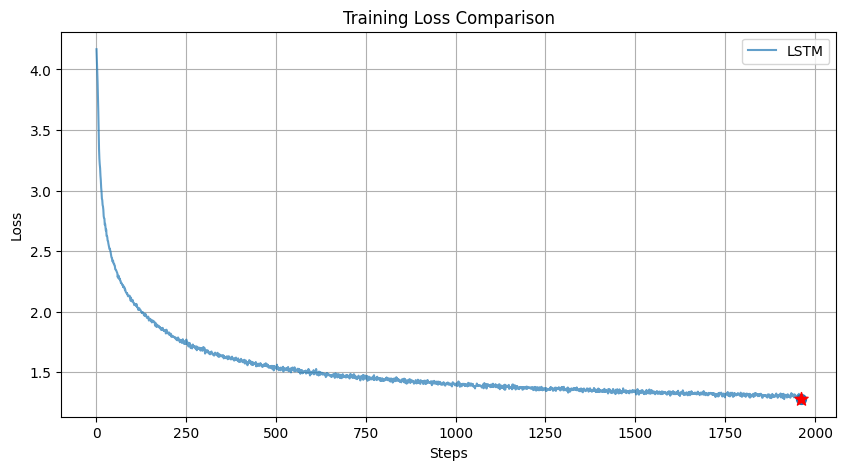

In [ ]:
# After you've added multiple models, plot the comparison
plot_loss_comparisons()

## LLama1 Implementation

In the previous code, we have already examined the detailed implementation of LLaMA 1. Please refer to the linked resource for a deeper explanation of the LLaMA 1 implementation.

In [ ]:
def generate_text_attention(model, char_to_idx, idx_to_char, start_text, device, max_length=500):
    model.eval()
    current_text = start_text

    with torch.no_grad():
        for _ in range(max_length):
            # Convert the last sequence of characters to indices and feed it to the model
            x = torch.tensor([[char_to_idx[ch] for ch in current_text[-SEQUENCE_LENGTH:]]]).to(device)
            output = model(x)[0]  # No hidden state needed for attention-based models
            probs = torch.softmax(output[0, -1], dim=0)
            next_char_idx = torch.multinomial(probs, 1).item()
            next_char = idx_to_char[next_char_idx]
            current_text += next_char

    return current_text

In [ ]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import math

# RoPE: Rotary Position Embedding function
def apply_rotary_pos_emb(q, k, sin, cos):
    q_rot = (q * cos) + (rotate_half(q) * sin)
    k_rot = (k * cos) + (rotate_half(k) * sin)
    return q_rot, k_rot

def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)


# Building the RoPE cache once, to be shared across layers
class RoPECache:
    def __init__(self, seq_len, head_dim, device):
        self.sin, self.cos = self.build_rope_cache(seq_len, head_dim, device)

    @staticmethod
    def build_rope_cache(seq_len, head_dim, device):
        inv_freq = 1.0 / (10000 ** (torch.arange(0, head_dim, 2).float().to(device) / head_dim))
        t = torch.arange(seq_len, device=device).float()
        freqs = torch.einsum('i,j->ij', t, inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        sin, cos = emb.sin(), emb.cos()
        return sin, cos

# Custom RMSNorm to match LLaMA 1 official implementation
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super(RMSNorm, self).__init__()
        self.weight = nn.Parameter(torch.ones(d_model))
        self.eps = eps

    def _norm(self, x):
        # Compute variance and apply reciprocal square root for RMS normalization
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

    def forward(self, x):
        # Convert to float32 for precision, then back to original dtype
        output = self._norm(x.float()).type_as(x)
        return output * self.weight

# Feed-Forward Network with implicit gating
class FeedForward(nn.Module):
    def __init__(self, d_model, multiple_of):
        super(FeedForward, self).__init__()
        up_hidden_dim = multiple_of * math.ceil((d_model * 4 * 2 / 3) / multiple_of)
        self.gate_proj = nn.Linear(d_model, up_hidden_dim, bias=False)
        self.up_proj = nn.Linear(d_model, up_hidden_dim, bias=False)
        self.down_proj = nn.Linear(up_hidden_dim, d_model, bias=False)
        self.act_fn = F.silu  # SiLU activation

    def forward(self, x):
        return self.down_proj(self.act_fn(self.gate_proj(x)) * self.up_proj(x))

# Multi-Head Attention with Causal Masking and RoPE
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, seq_length, rope_cache):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.head_dim = d_model // num_heads
        self.seq_length = seq_length

        self.query = nn.Linear(d_model, d_model, bias=False)
        self.key = nn.Linear(d_model, d_model, bias=False)
        self.value = nn.Linear(d_model, d_model, bias=False)
        self.fc_out = nn.Linear(d_model, d_model, bias=False)

        # Use the shared RoPE cache
        self.rope_cache = rope_cache

    def forward(self, x, mask=None):
        batch_size, seq_length, _ = x.size()
        Q = self.query(x).view(batch_size, seq_length, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.key(x).view(batch_size, seq_length, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.value(x).view(batch_size, seq_length, self.num_heads, self.head_dim).transpose(1, 2)

        # Apply RoPE to Q and K
        sin, cos = self.rope_cache.sin[:seq_length, :].to(x.device), self.rope_cache.cos[:seq_length, :].to(x.device)
        Q_rot, K_rot = apply_rotary_pos_emb(Q, K, sin, cos)

        # Scaled dot-product attention
        attention_scores = torch.matmul(Q_rot, K_rot.transpose(-2, -1)) / (self.head_dim ** 0.5)
        if mask is not None:
            attention_scores = attention_scores.masked_fill(mask == 0, float('-inf'))

        attention_probs = F.softmax(attention_scores, dim=-1)
        attention_output = torch.matmul(attention_probs, V)

        attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)
        return self.fc_out(attention_output)

# LLaMA Decoder Layer with Multi-Head Attention and RoPE
class LLaMADecoderLayer(nn.Module):
    def __init__(self, embedding_dim, multiple_of, num_heads, seq_length, rms_norm_eps, rope_cache):
        super(LLaMADecoderLayer, self).__init__()
        self.rmsnorm1 = RMSNorm(embedding_dim, rms_norm_eps)
        self.attention = MultiHeadAttention(embedding_dim, num_heads, seq_length, rope_cache)
        self.rmsnorm2 = RMSNorm(embedding_dim, rms_norm_eps)
        self.feed_forward = FeedForward(embedding_dim, multiple_of)

    def forward(self, x, mask):
        normed_x = self.rmsnorm1(x)
        attention_output = self.attention(normed_x, mask)
        x = x + attention_output  # Residual connection
        normed_x = self.rmsnorm2(x)
        feed_forward_output = self.feed_forward(normed_x)
        return x + feed_forward_output  # Residual connection

# LLaMA Model with RoPE and Multi-Layer
class LLaMAModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, seq_length, num_heads, num_layers, multiple_of, rms_norm_eps=1e-6):
        super(LLaMAModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # Initialize the shared RoPE cache once
        rope_cache = RoPECache(seq_length, embedding_dim // num_heads, torch.device('cpu'))

        self.layers = nn.ModuleList([LLaMADecoderLayer(embedding_dim, multiple_of, num_heads, seq_length, rms_norm_eps, rope_cache) for _ in range(num_layers)])
        self.rmsnorm_f = RMSNorm(embedding_dim, rms_norm_eps)
        self.fc_out = nn.Linear(embedding_dim, vocab_size, bias=False)

    def forward(self, idx, targets=None):
        x = self.embedding(idx)
        seq_length = x.size(1)
        mask = torch.tril(torch.ones(seq_length, seq_length)).to(x.device)

        for layer in self.layers:
            x = layer(x, mask)

        x = self.rmsnorm_f(x)
        logits = self.fc_out(x)

        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            return logits, loss
        return logits, None

In [ ]:
def train_and_test(model_desc, start_text, multiple_of, num_heads, num_layers):
    # Initialize the model
    model_llama = LLaMAModel(vocab_size, EMBEDDING_DIM, SEQUENCE_LENGTH, num_heads, num_layers, multiple_of).to(device)

    # Use the same optimizer and criterion
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_llama.parameters(), lr=LEARNING_RATE)

    # Train the model
    trained_model, train_losses_df, val_losses_df = train_model(
        model_llama, train_loader, val_loader, criterion, optimizer, device, EPOCHS
    )

    # Generate text
    generated_text = generate_text_attention(trained_model, char_to_idx, idx_to_char, start_text, device)
    print(f"Generated text [{start_text}]:")
    print("-"*50)
    print(generated_text)

    add_loss_to_comparison(model_desc, train_losses_df, val_losses_df)

    # Plot loss comparisons including this model
    plot_loss_comparisons()

Epoch 1/1
Epoch 1, Step 10, Batch 10/1961, Loss: 2.6026
Epoch 1, Step 20, Batch 20/1961, Loss: 2.4121
Epoch 1, Step 30, Batch 30/1961, Loss: 2.2893
Epoch 1, Step 40, Batch 40/1961, Loss: 2.1798
Epoch 1, Step 50, Batch 50/1961, Loss: 2.0651
Epoch 1, Step 60, Batch 60/1961, Loss: 1.9484
Epoch 1, Step 70, Batch 70/1961, Loss: 1.8768
Epoch 1, Step 80, Batch 80/1961, Loss: 1.7896
Epoch 1, Step 90, Batch 90/1961, Loss: 1.7377
Epoch 1, Step 100, Batch 100/1961, Loss: 1.6699
Epoch 1, Step 110, Batch 110/1961, Loss: 1.6277
Epoch 1, Step 120, Batch 120/1961, Loss: 1.5761
Epoch 1, Step 130, Batch 130/1961, Loss: 1.5382
Epoch 1, Step 140, Batch 140/1961, Loss: 1.5058
Epoch 1, Step 150, Batch 150/1961, Loss: 1.4946
Epoch 1, Step 160, Batch 160/1961, Loss: 1.4920
Epoch 1, Step 170, Batch 170/1961, Loss: 1.4443
Epoch 1, Step 180, Batch 180/1961, Loss: 1.4246
Epoch 1, Step 190, Batch 190/1961, Loss: 1.4116
Epoch 1, Step 200, Batch 200/1961, Loss: 1.4196
Epoch 1, Step 210, Batch 210/1961, Loss: 1.3728


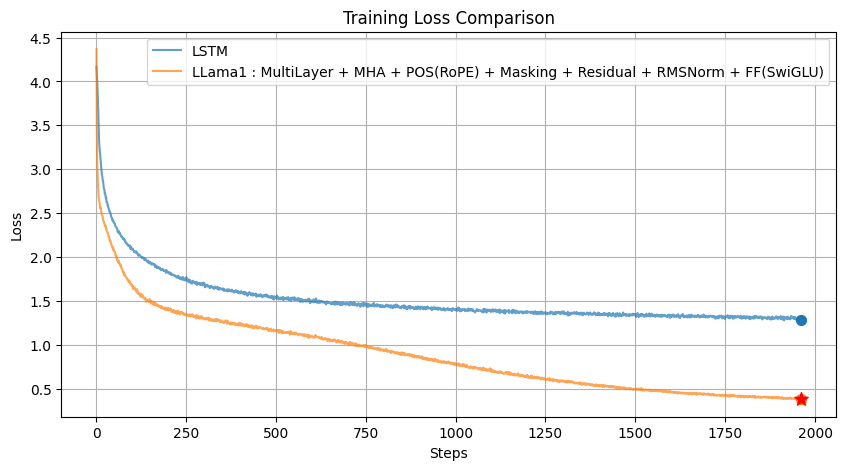

In [ ]:
multiple_of = 8   # roughly dim * 1/16
num_heads = 8
num_layers = 6

train_and_test("LLama1 : MultiLayer + MHA + POS(RoPE) + Masking + Residual + RMSNorm + FF(SwiGLU)", start_text, multiple_of, num_heads, num_layers)

With multiple layers, we see a significant improvement in the loss curve and generated text quality. The model is now capable of producing grammatically correct sentences with more coherent meaning. This demonstrates the power of deep transformers, which become more effective as the number of layers increases.

## LLaMA 2 Overview (Comparing LLaMA 1 and LLaMA 2)

| **Aspect**             | **LLaMA 1**                     | **LLaMA 2**                               |
|------------------------|----------------------------------|--------------------------------------------|
| **Attention Mechanism** | Standard Multi-Head Attention    | Grouped Query Attention (GQA)              |
| **Performance Focus**   | Single query/key head per attention group | Grouped keys and values per attention head |
| **Model Scaling**       | Efficient up to mid-sized models | Enhanced for large-scale models (70B+)     |
| **Positional Encoding** | Rotary Positional Embedding      | Same as LLaMA 1                            |





### Comparing Original Multi-Head Attention (MHA) with LLaMA 2's GQA Implementation

Both the original MHA and LLaMA 2's GQA implementations are based on similar principles of query-key-value (QKV) attention mechanisms, but the key difference lies in how they manage the number of projections and the introduction of Grouped Query Attention (GQA) in LLaMA 2. Here's a detailed comparison and explanation of why the LLaMA 2 approach is more efficient, particularly for large-scale models.

#### Original Multi-Head Attention (MHA)

In the original MHA implementation, each query, key, and value is projected individually for every attention head. The structure is as follows:
- **Query (Q), Key (K), and Value (V)**: For each attention head, a separate linear projection is applied.
- **RoPE (Rotary Positional Embedding)**: RoPE is applied to both Q and K to introduce positional information.
- **Dot-Product Attention**: The scaled dot-product is computed between Q and K for each head, followed by softmax to compute attention weights, which are then used to get the weighted sum over V.
- **No Grouping**: Each attention head handles its own set of QKV projections independently.

This approach is highly effective for models with smaller head counts and moderate scaling, but for very large models, it becomes inefficient due to the high computational cost of projecting separate keys and values for every head.

#### LLaMA 2's Grouped Query Attention (GQA)

LLaMA 2 introduces **Grouped Query Attention (GQA)**, which addresses the inefficiency in scaling by reducing the number of key and value projections. Here's how it differs:
- **Grouped Key and Value Projections**: Instead of creating individual K and V projections for every query head, LLaMA 2 introduces a grouping mechanism where multiple query heads share the same set of K and V projections. Specifically, the number of key-value heads is reduced by dividing the total number of heads by a group size (`num_groups`). For example, if there are 16 attention heads and the group size is 4, only 4 key-value projections are created.
- **Query Remains Independent**: Each query head still maintains its own projection, which ensures that the model can still distinguish between different parts of the input sequence.
- **Efficiency Gains**: By reducing the number of K and V projections, the model reduces memory usage and computational overhead, making it more scalable for larger models (e.g., 70B parameters or more).

#### Why LLaMA 2's Implementation is Necessary for Larger Models

1. **Memory Efficiency**: As models scale up to billions of parameters, the memory required to maintain separate K and V projections for each attention head becomes prohibitively expensive. GQA helps to mitigate this by sharing K and V across multiple heads, reducing the overall memory footprint.
   
2. **Faster Computation**: Fewer K and V projections mean fewer matrix multiplications during the attention calculation, which results in faster computation times, especially for models that need to process long sequences or have many attention heads.
   
3. **Scalability**: LLaMA 2's GQA is designed for extremely large models. For instance, LLaMA 2 models with 70B parameters or more utilize GQA to achieve state-of-the-art performance while keeping the model efficient and tractable to train and use.

#### Summary of Key Differences

| **Aspect**                 | **Original MHA**                                 | **LLaMA 2 GQA**                                 |
|----------------------------|--------------------------------------------------|--------------------------------------------------|
| **Q, K, V Projections**     | Each head has independent Q, K, V projections    | Query heads remain independent, but K, V are shared across groups |
| **Grouping Mechanism**      | No grouping; full Q, K, V projections per head   | K and V are grouped across multiple query heads  |
| **Efficiency**              | Less efficient for large models (high memory cost) | More efficient, especially for large-scale models (70B+) |
| **Targeted Model Size**     | Suitable for smaller to medium-sized models      | Optimized for large-scale models (e.g., 70B+ parameters) |
| **Use Case**                | Best for moderate-scale models                   | Essential for scaling to massive model sizes     |

In summary, LLaMA 2's GQA is a significant advancement for scaling attention-based models efficiently. It enables the model to handle much larger architectures without compromising on performance, making it a key feature for state-of-the-art, large-scale models.


### Implementation of Grouped Query Attention (GQA)

In [ ]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import math

# RoPE: Rotary Position Embedding function
def apply_rotary_pos_emb(q, k, sin, cos):
    q_rot = (q * cos) + (rotate_half(q) * sin)
    k_rot = (k * cos) + (rotate_half(k) * sin)
    return q_rot, k_rot

def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)

# Building the RoPE cache once, to be shared across layers
class RoPECache:
    def __init__(self, seq_len, head_dim, device):
        self.sin, self.cos = self.build_rope_cache(seq_len, head_dim, device)

    @staticmethod
    def build_rope_cache(seq_len, head_dim, device):
        inv_freq = 1.0 / (10000 ** (torch.arange(0, head_dim, 2).float().to(device) / head_dim))
        t = torch.arange(seq_len, device=device).float()
        freqs = torch.einsum('i,j->ij', t, inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        sin, cos = emb.sin(), emb.cos()
        return sin, cos

# Custom RMSNorm to match LLaMA official implementation
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super(RMSNorm, self).__init__()
        self.weight = nn.Parameter(torch.ones(d_model))
        self.eps = eps

    def _norm(self, x):
        # Compute variance and apply reciprocal square root for RMS normalization
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

    def forward(self, x):
        # Convert to float32 for precision, then back to original dtype
        output = self._norm(x.float()).type_as(x)
        return output * self.weight


# Feed-Forward Network with implicit gating
class FeedForward(nn.Module):
    def __init__(self, d_model, multiple_of, ffn_dim_multiplier=None):
        super(FeedForward, self).__init__()

        hidden_dim = 4 * d_model

        hidden_dim = int(2 * hidden_dim / 3)
        if ffn_dim_multiplier is not None:
            hidden_dim = int(ffn_dim_multiplier * hidden_dim)

        up_hidden_dim = multiple_of * ((hidden_dim + multiple_of - 1) // multiple_of)

        self.gate_proj = nn.Linear(d_model, up_hidden_dim, bias=False)
        self.up_proj = nn.Linear(d_model, up_hidden_dim, bias=False)
        self.down_proj = nn.Linear(up_hidden_dim, d_model, bias=False)
        self.act_fn = F.silu  # SiLU activation

    def forward(self, x):
        gate = self.gate_proj(x)
        up = self.up_proj(x)
        activated = self.act_fn(gate) * up

        output = self.down_proj(activated)
        return output


# Core Explanation of the LLaMA 2 Implementation
"""
The core of the LLaMA 2 implementation lies in Grouped Query Attention (GQA).
In GQA, we reduce the number of key-value projections while maintaining multiple query projections.
This grouping mechanism allows for more efficient processing, especially in large models, by sharing keys and values among multiple query heads.
This is what differentiates LLaMA 2 from LLaMA 1, which uses standard attention mechanisms.
"""
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, seq_length, num_groups, rope_cache):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.head_dim = d_model // num_heads
        self.seq_length = seq_length


        ##############################

        ######    GQA로 작성  #########

        ##############################

        self.query =
        self.key =
        self.value =
        self.fc_out =

        # Use the shared RoPE cache
        self.rope_cache = rope_cache

    def forward(self, x, mask=None):
        batch_size, seq_length, _ = x.size()


        ##############################

        ######    GQA로 작성  #######

        ##############################

        return x

# Updated LLaMADecoderLayer
class LLaMADecoderLayer(nn.Module):
    def __init__(self, embedding_dim, multiple_of, num_heads, num_groups, seq_length, rms_norm_eps, rope_cache):
        super(LLaMADecoderLayer, self).__init__()
        self.rmsnorm1 = RMSNorm(embedding_dim, rms_norm_eps)
        self.attention = MultiHeadAttention(embedding_dim, num_heads, seq_length, num_groups, rope_cache)
        self.rmsnorm2 = RMSNorm(embedding_dim, rms_norm_eps)
        self.feed_forward = FeedForward(embedding_dim, multiple_of)

    def forward(self, x, mask):
        normed_x = self.rmsnorm1(x)
        attention_output = self.attention(normed_x, mask)
        x = x + attention_output
        normed_x = self.rmsnorm2(x)
        feed_forward_output = self.feed_forward(normed_x)
        return x + feed_forward_output

# Updated LLaMA2Model with num_groups
class LLaMA2Model(nn.Module):
    def __init__(self, vocab_size, embedding_dim, seq_length, num_heads, num_groups, num_layers, multiple_of, rms_norm_eps=1e-5):
        super(LLaMA2Model, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # Initialize the shared RoPE cache once
        rope_cache = RoPECache(seq_length, embedding_dim // num_heads, torch.device('cpu'))

        self.layers = nn.ModuleList([
            LLaMADecoderLayer(embedding_dim, multiple_of, num_heads, num_groups, seq_length, rms_norm_eps, rope_cache)
            for _ in range(num_layers)
        ])
        self.rmsnorm_f = RMSNorm(embedding_dim, rms_norm_eps)
        self.fc_out = nn.Linear(embedding_dim, vocab_size, bias=False)

    def forward(self, idx, targets=None):
        x = self.embedding(idx)
        seq_length = x.size(1)
        mask = torch.tril(torch.ones(seq_length, seq_length)).to(x.device)

        for layer in self.layers:
            x = layer(x, mask)

        x = self.rmsnorm_f(x)
        logits = self.fc_out(x)

        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            return logits, loss
        return logits, None

### Code Comparison: Original Multi-Head Attention (MHA) vs LLaMA 2's Grouped Query Attention (GQA)

#### 1. Key Differences in Projections for Key (K) and Value (V)

In the **original MHA** implementation, the key and value projections (`K`, `V`) are computed independently for each attention head, while in **LLaMA 2's GQA**, multiple query heads share the same key and value projections to reduce the number of parameters and computations.

**Original MHA Code:**
```python
K = self.key(x).view(batch_size, seq_length, self.num_heads, self.head_dim).transpose(1, 2)
V = self.value(x).view(batch_size, seq_length, self.num_heads, self.head_dim).transpose(1, 2)
```

- **Explanation**: In the original MHA, `K` and `V` are projected for each of the `num_heads` heads, meaning every head has its own independent key and value projection.

**LLaMA 2 GQA Code:**
```python
K = self.key(x).view(batch_size, seq_length, self.num_kv_heads, self.head_dim).transpose(1, 2)
V = self.value(x).view(batch_size, seq_length, self.num_kv_heads, self.head_dim).transpose(1, 2)
```

- **Explanation**: In LLaMA 2's GQA, `num_kv_heads` is calculated as `num_heads // num_groups`. This means instead of projecting keys and values for each attention head, we reduce the number of key-value projections by grouping multiple query heads together to share the same key and value projections.

#### 2. Query Projections Remain the Same

In both the **original MHA** and **LLaMA 2 GQA**, the query projections (`Q`) remain independent for each head. This is because each head needs to generate a different query to attend to different parts of the input.

**Original MHA Code:**
```python
Q = self.query(x).view(batch_size, seq_length, self.num_heads, self.head_dim).transpose(1, 2)
```

**LLaMA 2 GQA Code:**
```python
Q = self.query(x).view(batch_size, seq_length, self.num_heads, self.head_dim).transpose(1, 2)
```

- **Explanation**: Both versions project queries independently for each attention head. There is no change here because each head still needs a distinct query to focus on different parts of the sequence.

#### 3. Key and Value Projections are Repeated for Grouped Heads in GQA

One of the key differences in **LLaMA 2 GQA** is that after projecting the keys and values, they are **repeated** to match the number of query heads. This allows the model to share key-value pairs across multiple query heads.

**LLaMA 2 GQA Code (New Mechanism):**
```python
K_rot = K_rot.repeat_interleave(self.num_heads // self.num_kv_heads, dim=1)
V = V.repeat_interleave(self.num_heads // self.num_kv_heads, dim=1)
```

- **Explanation**: After the key and value projections are calculated for the reduced number of key-value heads (`num_kv_heads`), the projections are repeated using `repeat_interleave()` to match the number of query heads (`num_heads`). This ensures that all query heads share the same key-value projections in groups, which reduces computational costs and memory requirements, especially for large models.


#### Summary of Key Changes

| **Aspect**            | **Original MHA**                                     | **LLaMA 2 GQA**                                    |
|-----------------------|-----------------------------------------------------|----------------------------------------------------|
| **Key/Value Projections** | Independent per head (`num_heads` projections)       | Grouped per `num_kv_heads` (reduced projections)   |
| **Query Projections**  | Independent per head                                | Same as original (independent per head)            |
| **Repetition of K/V**  | No repetition                                       | `repeat_interleave` for grouped key-value heads    |


In [ ]:
def train_and_test(model_desc, start_text, multiple_of, num_heads, num_layers, num_groups):
    # Initialize the model
    model_llama2 = LLaMA2Model(
        vocab_size=vocab_size,
        embedding_dim=EMBEDDING_DIM,
        seq_length=SEQUENCE_LENGTH,
        num_heads=num_heads,
        num_groups=num_groups,
        num_layers=num_layers,
        multiple_of=multiple_of
    ).to(device)

    # Use the same optimizer and criterion
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_llama2.parameters(), lr=LEARNING_RATE)

    # Train the model
    trained_model, train_losses_df, val_losses_df = train_model(
        model_llama2, train_loader, val_loader, criterion, optimizer, device, EPOCHS
    )

    # Generate text
    generated_text = generate_text(trained_model, char_to_idx, idx_to_char, start_text, device)
    print(f"Generated text [{start_text}]:")
    print("-"*50)
    print(generated_text)

    add_loss_to_comparison(model_desc, train_losses_df, val_losses_df)

    # Plot loss comparisons including this model
    plot_loss_comparisons()

    return trained_model

# Example usage:
multiple_of = 32
num_heads = 8
num_layers = 6
num_groups = 2  # New parameter for LLaMA 2

trained_model = train_and_test(
    "LLama2 : MultiLayer + MHA(GQA) + POS(RoPE) + Masking + Residual + RMSNorm + FF(SwiGLU)",
    start_text="Once upon a time",
    multiple_of=multiple_of,
    num_heads=num_heads,
    num_layers=num_layers,
    num_groups=num_groups,
)

# Print model structure and GQA details
print(f"Number of heads: {num_heads}")
print(f"Number of query heads per KV head: {num_groups}")

### Performance Comparison

In practice, the performance differences between small LLaMA 1 and LLaMA 2 models are minimal.

In fact, LLaMA 2 only introduces GQA support in models that are 70B parameters or larger. In this lecture, we applied GQA to a small toy model for educational purposes.
